# Exploratory data analysis (EDA)

EDA is used for understanding the dataset. When you get some data to analyze, the first step usually is to read it, and then perform EDA.

During the EDA process, you will

- understand the data
- visualize a lot
- find trends
- ask questions and try to answer them with the data
- be curious
- document your findings
- data cleaning


In [1]:
import pandas as pd 

df = pd.read_csv("salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M


## initial EDA

In [2]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='str')

In [3]:
df.shape

(16534, 11)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16534 entries, 0 to 16533
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           16534 non-null  int64
 1   experience_level    16534 non-null  str  
 2   employment_type     16534 non-null  str  
 3   job_title           16534 non-null  str  
 4   salary              16534 non-null  int64
 5   salary_currency     16534 non-null  str  
 6   salary_in_usd       16534 non-null  int64
 7   employee_residence  16534 non-null  str  
 8   remote_ratio        16534 non-null  int64
 9   company_location    16534 non-null  str  
 10  company_size        16534 non-null  str  
dtypes: int64(4), str(7)
memory usage: 1.4 MB


In [5]:
pd.__version__

'3.0.1'

In [6]:
df["work_year"].value_counts()

work_year
2023    8519
2024    6067
2022    1655
2021     218
2020      75
Name: count, dtype: int64

In [7]:
df["company_location"].value_counts().head(10)

company_location
US    14518
GB      694
CA      455
ES      133
DE      105
FR       65
IN       63
AU       57
NL       32
PT       28
Name: count, dtype: int64

change the experience levels to
- SE -> Senior
- MI -> Mid
- EN -> Entry
- EX -> Expert

In [8]:
df["experience_level"].value_counts()

experience_level
SE    10670
MI     4038
EN     1325
EX      501
Name: count, dtype: int64

In [9]:
df["salary_currency"].value_counts().head()

salary_currency
USD    15294
GBP      616
EUR      449
CAD       56
INR       55
Name: count, dtype: int64

can we combine salary in USD with job role 
- e.g. group by and median for each job role

In [10]:
df["salary_in_usd"].head()

0    202730
1     92118
2    130500
3     96000
4    190000
Name: salary_in_usd, dtype: int64

want to change names

- M -> Medium
- L -> Large
- S -> Small


In [11]:
df["company_size"].value_counts()

company_size
M    15306
L     1040
S      188
Name: count, dtype: int64

we note that there is Data Scientist and there is Data Science -> so there are several roles that actually are same but written in different ways. Let's clean that

In [12]:
df["job_title"].value_counts().head(10)

job_title
Data Engineer                3464
Data Scientist               3314
Data Analyst                 2440
Machine Learning Engineer    1705
Research Scientist            531
Applied Scientist             435
Data Architect                435
Analytics Engineer            431
Research Engineer             306
Data Science                  271
Name: count, dtype: int64

## Cleaning job titles

In [19]:
import duckdb 

duckdb.sql("""--sql
FROM df
WHERE job_title ILIKE 'data scien%'
""").df()["job_title"].value_counts()

job_title
Data Scientist               3314
Data Science                  271
Data Science Manager          122
Data Science Consultant        83
Data Science Engineer          29
Data Science Lead              26
Data Science Practitioner      16
Data Science Director           8
Data Science Analyst            4
Data Scientist Lead             2
Data Science Tech Lead          1
Name: count, dtype: int64

In [20]:
duckdb.sql("""--sql
FROM df
WHERE job_title ILIKE 'data eng%'
""").df()["job_title"].value_counts()

job_title
Data Engineer    3464
Name: count, dtype: int64

In [21]:
duckdb.sql("""--sql
FROM df
WHERE job_title ILIKE 'data analy%'
""").df()["job_title"].value_counts()

job_title
Data Analyst                 2440
Data Analytics Manager         62
Data Analytics Lead            23
Data Analytics Specialist       8
Data Analytics Consultant       8
Data Analytics Engineer         5
Data Analyst Lead               2
Data Analytics Associate        1
Name: count, dtype: int64

In [24]:
duckdb.sql("""--sql
FROM df
WHERE job_title ILIKE 'machine learning%engineer%'
""").df()["job_title"].value_counts()

job_title
Machine Learning Engineer                   1705
Machine Learning Infrastructure Engineer      33
Machine Learning Software Engineer            15
Machine Learning Operations Engineer           9
Machine Learning Research Engineer             5
Name: count, dtype: int64

clean data

TODO: for reader clean it further

In [31]:
df_cleaned = duckdb.sql("""--sql
SELECT 
    * EXCLUDE(job_title, experience_level),
    CASE 
        WHEN job_title ILIKE 'data scien%' THEN 'Data Scientist'
        WHEN job_title ILIKE 'data analy%' THEN 'Data Analyst'
        WHEN job_title ILIKE 'machine learning%engineer%' THEN 'Machine Learning Engineer'
        ELSE job_title
    END AS job_title,
    CASE 
        WHEN experience_level = 'EN' THEN 'Entry'
        WHEN experience_level = 'MI' THEN 'Mid'
        WHEN experience_level = 'SE' THEN 'Senior'
        WHEN experience_level = 'EX' THEN 'Expert'
        END AS experience_level
FROM df                   
""").df()

df_cleaned["job_title"].value_counts().head()

job_title
Data Scientist               3876
Data Engineer                3464
Data Analyst                 2549
Machine Learning Engineer    1767
Research Scientist            531
Name: count, dtype: int64

In [34]:
df_cleaned["experience_level"].value_counts()

experience_level
Senior    10670
Mid        4038
Entry      1325
Expert      501
Name: count, dtype: int64

## Export cleaned dataset

In [36]:
df_cleaned.to_csv("salaries_cleaned.csv")

## Visualizations

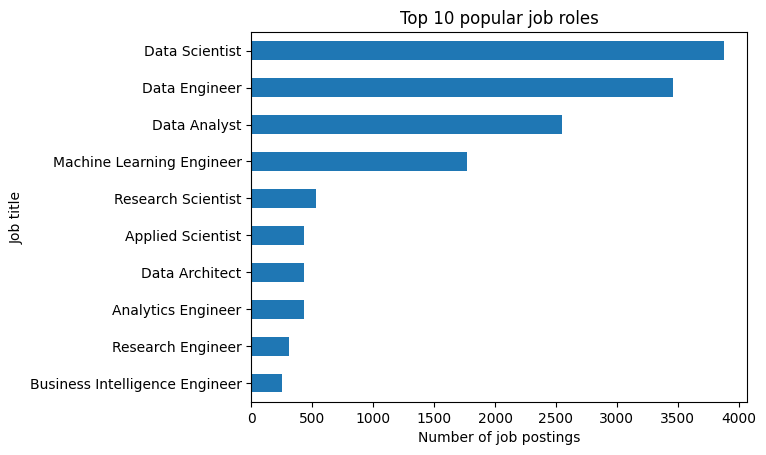

In [44]:
ax = df_cleaned["job_title"].value_counts().head(10).plot(
    kind="barh",
    title="Top 10 popular job roles",
    xlabel="Number of job postings",
    ylabel="Job title",
)

ax.invert_yaxis()


In [45]:
df_cleaned.head()

,work_year,employment_type,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,job_title,experience_level
0,2024,FT,202730,USD,202730,US,0,US,M,AI Engineer,Senior
1,2024,FT,92118,USD,92118,US,0,US,M,AI Engineer,Senior
2,2024,FT,130500,USD,130500,US,0,US,M,Data Engineer,Senior
3,2024,FT,96000,USD,96000,US,0,US,M,Data Engineer,Senior
4,2024,FT,190000,USD,190000,US,0,US,M,Machine Learning Engineer,Senior


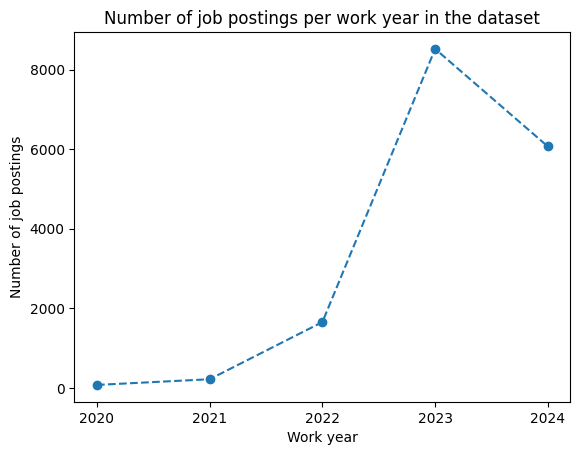

In [ ]:
import matplotlib.pyplot as plt

ax = (
    df_cleaned["work_year"]
    .value_counts()
    .sort_index()
    .plot(
        linestyle="--",
        marker="o",
        xlabel="Work year",
        ylabel="Number of job postings",
        title="Number of job postings per work year in the dataset",
    )
)

ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))